# MiniProject 1: What Words Do These Books Use Most?
**Me:** jzr266  **Group:** 11

I picked three creepy old books and wanted to see which words each one leans on the most. Moby Dick is all about whales and the sea, and Call of Cthulhu is eldritch horror, so I was curious whether that shared spooky-sea vibe made them use similar words, or whether each author has their own go-to vocabulary. The plan: use Python to read the text and count how often each word shows up.

- The Call of Cthulhu: https://www.gutenberg.org/ebooks/68283  (H. P. Lovecraft)
- The Shunned House: https://www.gutenberg.org/ebooks/31469  (H. P. Lovecraft)
- Moby-Dick: https://www.gutenberg.org/ebooks/2701  (Herman Melville)

## Three things I want to find out
1. **Same writer:** do two Lovecraft stories (*Call of Cthulhu* and *The Shunned House*) use words the same way?
2. **Different writers:** how does Lovecraft stack up against Melville (*Moby Dick*)?
3. **Signature words:** which words does one author reach for a lot that the other barely touches?

## Getting set up
Loading the tools I need and building a list of boring words to ignore (things like *the, and, is*, plus leftover punctuation) so they don't drown out the interesting words.

In [1]:
import re, operator, math
from collections import Counter
from bs4 import BeautifulSoup
import nltk
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

nltk.download('stopwords', quiet=True)

# stop words we ignore (common function words + punctuation left over after cleaning)
stop_words = set(nltk.corpus.stopwords.words('english')) | {
    'ut', "'re", '.', ',', '--', "'s", '?', ')', '(', ':', "'",
    '"', '-', '}', '{', '&', '|', u'\u2014', '',
}

## Cleaning up the text first
These books come as web pages, so they're full of HTML tags and a big Project Gutenberg legal notice at the top and bottom. If I don't clean that out, words like *gutenberg* and *license* show up in every book and mess up the comparison. So I strip the HTML, cut off the legal boilerplate, make everything lowercase, peel punctuation off the edges of words, toss out numbers, and drop the boring words. What's left is the actual story vocabulary.

In [2]:
def clean_word(w):
    # remove punctuation stuck to a word
    wn = re.sub(r'[,"\.\'&\|:@>*;/=!\?\)\(\[\]]', '', w)
    # drop pure numbers
    return re.sub(r'^[0-9\.]*$', '', wn)

def strip_gutenberg(text):
    # keep only the body between the *** START *** / *** END *** markers
    start = re.search(r'\*\*\* *START OF TH.*? \*\*\*', text, re.IGNORECASE)
    if start:
        text = text[start.end():]
    end = re.search(r'\*\*\* *END OF TH.*? \*\*\*', text, re.IGNORECASE)
    if end:
        text = text[:end.start()]
    return text

def get_wf(path):
    """Return (Counter of word frequencies, total regular-word count)."""
    with open(path, 'r', encoding='utf-8', errors='replace') as f:
        html = f.read()
    text = BeautifulSoup(html, 'html.parser').get_text()
    text = strip_gutenberg(text).lower()
    wds = [clean_word(w) for w in re.split(r'\s+', text)]
    wf = Counter(wds)
    for k in stop_words:
        wf.pop(k, None)
    return wf, sum(wf.values())

## Reading in the three books
Now I load each book and print how many real words are left after cleaning. Heads up: Moby Dick is way longer than the two Lovecraft stories, which matters later.

In [3]:
BOOKS = {
    'Cthulhu (Lovecraft)':       'callOfCthulhu/pg68283-images.html',
    'Shunned House (Lovecraft)': 'theShunnedHouse/pg31469-images.html',
    'Moby Dick (Melville)':      'mobyDick/pg2701-images.html',
}

wf = {}
totals = {}
for name, path in BOOKS.items():
    wf[name], totals[name] = get_wf(path)
    print(f'{name:28s} regular words: {totals[name]:>7d}')

Cthulhu (Lovecraft)          regular words:    6272
Shunned House (Lovecraft)    regular words:    5598


Moby Dick (Melville)         regular words:  110166


### The 15 most-used words in each book
A quick look at what each book talks about most.

In [4]:
for name in BOOKS:
    print(f'\n=== {name} ===')
    for w, c in wf[name].most_common(15):
        print(f'  {w:15s}{c}')


=== Cthulhu (Lovecraft) ===
  could          37
  one            36
  men            31
  great          30
  professor      30
  cult           30
  would          28
  old            28
  dreams         25
  cthulhu        23
  man            23
  johansen       23
  found          22
  thing          21
  uncle          21

=== Shunned House (Lovecraft) ===
  house          57
  street         38
  one            34
  harris         31
  could          29
  seemed         27
  uncle          25
  would          21
  might          21
  door           20
  shunned        19
  cellar         19
  place          17
  thing          17
  old            16

=== Moby Dick (Melville) ===
  whale          923
  one            884
  like           571
  upon           562
  old            439
  would          427
  man            413
  ahab           409
  ye             396
  ship           372
  sea            367
  though         360
  yet            335
  time           319
  long      

## Setting up the bar charts
Since Moby Dick is so much longer, raw counts aren't a fair comparison, because a long book naturally has bigger numbers. So instead of raw counts I use a rate: how many times a word shows up *per 1000 words*. That way a short book and a long book are on equal footing. This function just draws two books side by side.

In [5]:
def top_rates(name, n=15):
    tot = totals[name]
    items = [(w, 1000.0 * c / tot) for w, c in wf[name].most_common(n)]
    return items[::-1]  # reverse: barh draws bottom-up

def plot_two(a, b, title):
    fa, fb = top_rates(a), top_rates(b)
    f = plt.figure(figsize=(12, 6))
    f.suptitle(title, fontsize=16)
    ax1 = f.add_subplot(121)
    ax1.barh(range(len(fa)), [x[1] for x in fa], align='center')
    ax1.set_yticks(range(len(fa)))
    ax1.set_yticklabels([x[0] for x in fa])
    ax1.set_title(a); ax1.set_xlabel('per 1000 words')
    ax2 = f.add_subplot(122)
    ax2.barh(range(len(fb)), [x[1] for x in fb], align='center', color='tab:orange')
    ax2.set_yticks(range(len(fb)))
    ax2.set_yticklabels([x[0] for x in fb])
    ax2.set_title(b); ax2.set_xlabel('per 1000 words')
    plt.subplots_adjust(wspace=0.4)
    plt.show()

## Question 1: Same author
Two Lovecraft stories next to each other: *Call of Cthulhu* vs *The Shunned House*. Do they feel like they came from the same person?

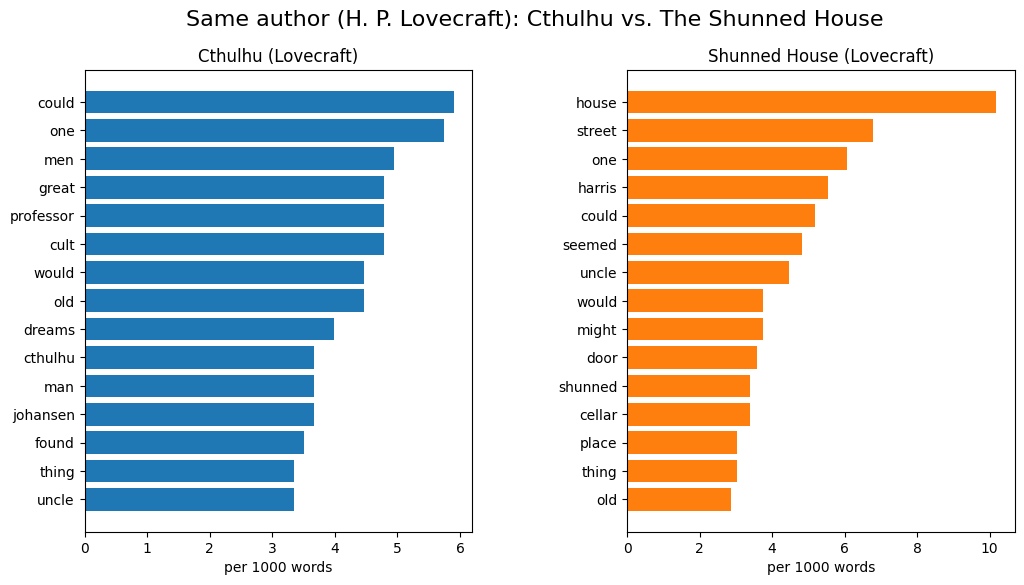

In [6]:
plot_two('Cthulhu (Lovecraft)', 'Shunned House (Lovecraft)',
         'Same author (H. P. Lovecraft): Cthulhu vs. The Shunned House')

## Question 2: Different authors
Now Lovecraft vs Melville: *Call of Cthulhu* vs *Moby Dick*. I'd expect these to look pretty different.

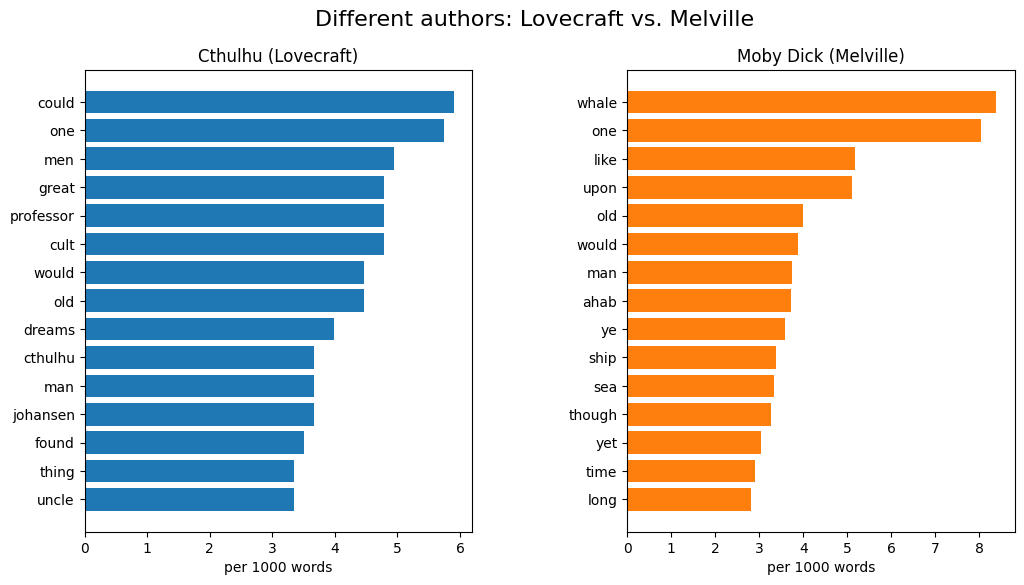

In [7]:
plot_two('Cthulhu (Lovecraft)', 'Moby Dick (Melville)',
         'Different authors: Lovecraft vs. Melville')

## Question 3: Each author's signature words
Here I combine both Lovecraft stories into one pile and compare it against Moby Dick, then pull out the words each author uses way more than the other. I only count words that show up enough times (more than 15 total) so I'm not chasing flukes.

In [8]:
lov = wf['Cthulhu (Lovecraft)'] + wf['Shunned House (Lovecraft)']
mel = wf['Moby Dick (Melville)']
lov_tot, mel_tot = sum(lov.values()), sum(mel.values())

def rate(counter, tot):
    return {w: 1000.0 * c / tot for w, c in counter.items()}

lr, mr = rate(lov, lov_tot), rate(mel, mel_tot)
common = set(lr) & set(mr)
diff = sorted(((w, lr[w] - mr[w]) for w in common if lov[w] + mel[w] > 15),
              key=operator.itemgetter(1))

print('Words MELVILLE favors over Lovecraft (rate diff per 1000):')
for w, d in diff[:12]:
    print(f'  {w:15s}{d:6.2f}')
print('\nWords LOVECRAFT favors over Melville (rate diff per 1000):')
for w, d in diff[-12:][::-1]:
    print(f'  {w:15s}{d:6.2f}')

Words MELVILLE favors over Lovecraft (rate diff per 1000):
  upon            -3.16
  ship            -3.04
  like            -2.91
  sea             -2.49
  captain         -2.29
  one             -2.13
  yet             -2.03
  round           -1.94
  boat            -1.85
  head            -1.71
  three           -1.53
  man             -1.47

Words LOVECRAFT favors over Melville (rate diff per 1000):
  house            4.84
  uncle            3.86
  street           3.68
  could            3.62
  harris           2.58
  professor        2.49
  dreams           2.46
  told             1.69
  earth            1.67
  door             1.66
  new              1.60
  stone            1.59


## What I found

- **Q1 (same author):** The two Lovecraft stories lean on a similar mood-setting, everyday vocabulary (*house, uncle, dreams, old, seemed*). Their top words overlap a good bit, so they feel like the same writer.
- **Q2 (different authors):** Moby Dick is wall-to-wall sea and whaling words (*whale, ship, sea, ahab, boat, captain*) that basically don't show up in Lovecraft at all.
- **Q3 (signature words):** Melville's go-to words are *ship, sea, captain, boat, like*; Lovecraft's are *house, uncle, street, professor, dreams*. So the shared spooky-sea vibe I expected didn't really show up. Each author has his own vocabulary.

### Stuff that tripped me up
- The Project Gutenberg legal text at the top and bottom of each book kept polluting the counts until I stripped it out.
- The common filler words (*the, and, of*) buried the interesting ones, so I had to remove them.
- Moby Dick being so much longer than the Lovecraft stories made raw counts misleading, so switching to a "per 1000 words" rate fixed that.